We start by examining an available dataset that is similar to our needs

We use the test set initially because it is smaller to just get started

In [1]:
import pandas as pd
from datasets import load_dataset

ds = load_dataset("tomekkorbak/python-github-code", split="test")
ds

Dataset({
    features: ['text', 'repo_name', 'path', 'language', 'license', 'size', 'score'],
    num_rows: 10000
})

We remove unnecessary columns like language and score

In [2]:
ds.set_format("pandas")
df = ds[:]

df.drop(columns=["language", "score"], axis=1, inplace=True)
df = df.rename(columns={"size": "NUM_CHARS"})
df

,text,repo_name,path,license,NUM_CHARS
0,from __future__ import print_function\r\n\r\ni...,Jeff-Tian/mybnb,Python27/Lib/test/test___all__.py,apache-2.0,4298
1,"# (c) 2012-2014, Michael DeHaan <michael.dehaa...",bootswithdefer/ansible,v2/ansible/playbook/__init__.py,gpl-3.0,3162
2,from __future__ import print_function\nfrom pa...,dssg/wikienergy,disaggregator/build/pandas/pandas/io/tests/tes...,mit,17790
3,"""""""\nOutlier Detection using Tukeys Filter Cla...",trademob/anna-molly,lib/plugins/tukeys_filter.py,mit,5255
4,## -*- Mode: python; py-indent-offset: 4; inde...,srene/ndnSIM-inrpp,src/ndnSIM/examples/ndn-simple.py,gpl-2.0,3286
...,...,...,...,...,...
9995,"from __future__ import absolute_import, unicod...",chrxr/wagtail,wagtail/wagtailsearch/tests/test_db_backend.py,bsd-3-clause,854
9996,from lib.action import BaseVMsAction\n\n__all_...,armab/st2contrib,packs/rackspace/actions/set_vm_metadata_item.py,apache-2.0,490
9997,#\n# Licensed to the Apache Software Foundatio...,practice-vishnoi/dev-spark-1,python/pyspark/mllib/__init__.py,apache-2.0,1208
9998,"import random,collections\n\ndef combine_fold(...",sysbio-vo/bnfinder,BNfinder/CrossVal.py,gpl-2.0,984


There are no nulls and dtypes are valid

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       10000 non-null  object
 1   repo_name  10000 non-null  object
 2   path       10000 non-null  object
 3   license    10000 non-null  object
 4   NUM_CHARS  10000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


Examining licenses shows that most data are safe to be used for training. We will avoid risky/conditional licenses

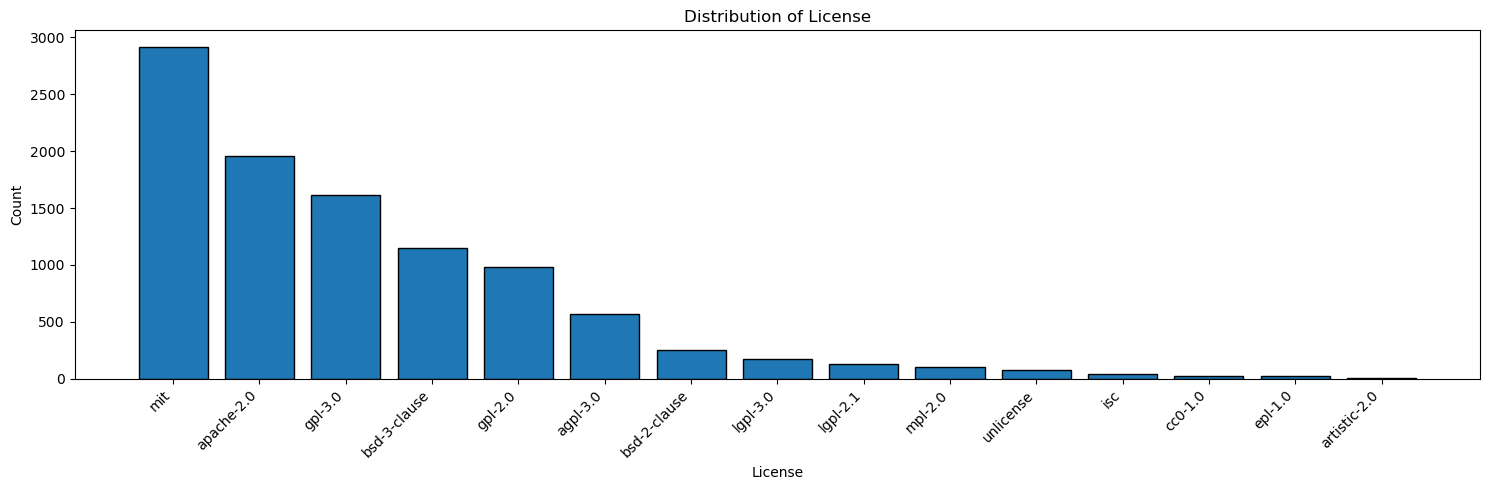

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(15, 5))
counts = df["license"].value_counts()

plt.bar(counts.index, counts.values, edgecolor="black")

plt.title("Distribution of License")
plt.xlabel("License")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [5]:
SAFE_LICENSES = [
    "mit",
    "apache-2.0",
    "bsd-3-clause",
    "bsd-2-clause",
    "isc",
    "cc0-1.0"
]

df = df[df["license"].isin(SAFE_LICENSES)]
print(f"{len(df)} examples remained")

6339 examples remained


Distribution of size is right-skewed

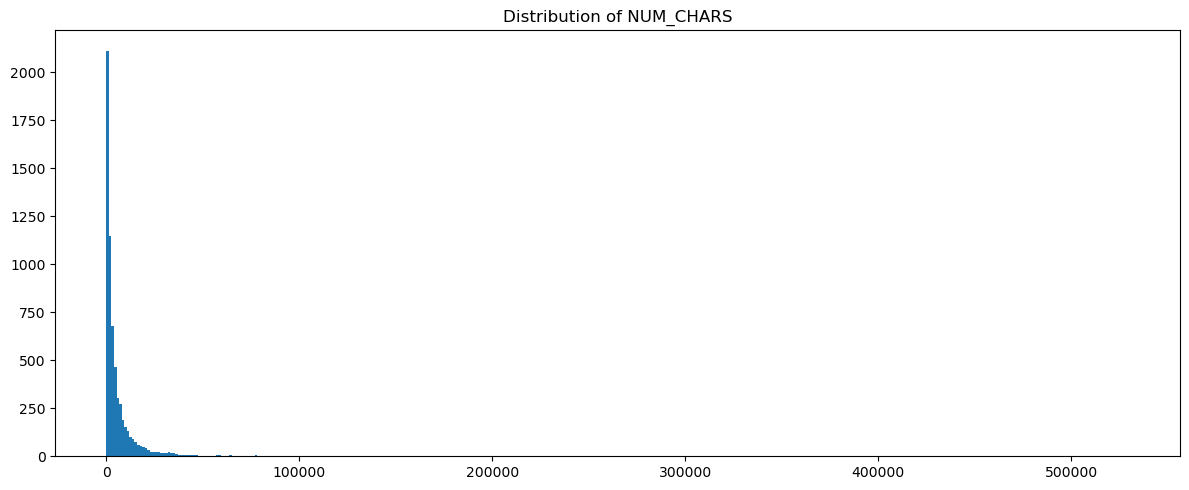

In [6]:
fig = plt.figure(figsize=(12,5))
plt.hist(df["NUM_CHARS"], bins=400)
plt.title("Distribution of NUM_CHARS")

plt.tight_layout()
plt.show()

Most example's NUM_CHARS is below 75k so we set this as a limit

In [8]:
df["NUM_CHARS"].quantile(0.99)

np.float64(73048.33999999994)

In [9]:
df = df[df["NUM_CHARS"] < 75000]
print(f"{len(df)} examples remained")

6280 examples remained


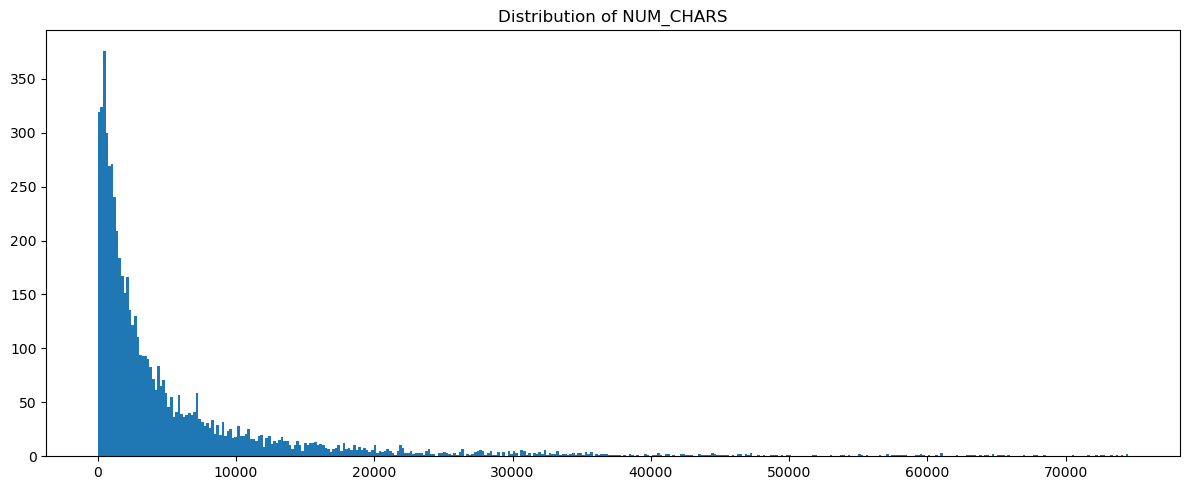

In [10]:
fig = plt.figure(figsize=(12,5))
plt.hist(df["NUM_CHARS"], bins=400)
plt.title("Distribution of NUM_CHARS")

plt.tight_layout()
plt.show()